# 1. Executive Summary 
This project implements and empirically evaluates several interpolation methods including: the global Barycentric-1 polnomial using chebyshev points with Leja's ordering, piecewise Newton interpolants, cubic Hermite interpolants, standard cubic splines, and the cubic B-spline. 

The Algorithms were developed using python with an emphasis on numerical stability and efficient evaluation. Validation and testing was preformed on smooth test functions, including: polynomials, $sin(x)$, and Runge's function, using error metrics such as the infinity norm, mean squarred error, and others. 

For the discrete data task, the methods were applied to recover the functions $y(t), f(t),$ and $D(t)$ from the nonuniformly spaced measurements coming from $y(t_i)$. The natural cubic spline was compared against the piecewise Newton interpolants for degree $d = 1,2,$ and $3$.

From validation, the cubic spline delivered the best smoothness and a consistent derivative, crucial for computing $f(t)=y(t)+ty'(t)$ and $D(t)=e^{-ty(t)}$. This constrasted heavily from the piecewise Newton approach which suffered from derivative discontinuities at the data nodes. 

The results highlight the strenghts and limitation for each method. The tests demonstrate that cubic splines provide the best balance of accuracy, smoothness, and reliability when derivative are required. 

# 2. Statement of the Problem
The objective of this program is to emperically analyze and validate the selected interpolation methods. These include the global interpolating polynomial $p_n(x)$, local piecewise interpolating polynomials $g_d(x)$, and cubic spline interpolation methods $s(x)$. 

The global interpolating polynomial is constructed using the Barycentric-1 form with Chebyshev points of the first kind to ensure convergence.

The piecewise interpolating polynomial is formed using the local divided differnce form and supports the option for piecewise Hermite cubic interpolation.

The interpolatory cubic spline is constructed using both the standard derivative parameterization and parameterization in terms of the cubic B-spline Basis. 

# 3. Description of the Mathematics

## 3.1 Interpolating Polynomial
The global interpolating polynomial consturcts a single polynomial $p_n(x) \in P_n$ satifying the conditions $$p_n(x) = f(x_i) \quad i = 1,...,n$$

This projects uses the Barycentric-1 form of the interpolating polynomial defined as 
$$p_n(x) =  w_{n+1}(x) \sum_{i=0}^n \frac{\gamma_i f(x_i)}{x-x_i} \quad  \text{where} \quad w_{n+1}(x) = \prod_{i=0}^n (x-x_i)$$

In this form, the weights are given by $$ \gamma_i = \frac{1}{\prod_{j \neq i}^n x_i - x_j}$$

Using this form, the weights can be precomputed for the polynomial evaluation, helping to imporve computational complexity and numerical stability associated with the method.

The Barycentric-1 form can be further improved upon by selecting chebyshev points for the mesh. This project uses the Chebyshev points of the first kind defined as 
$$x_i = cos(\frac{(2i+1)\pi}{2(n+1)}) \quad i = 0, ..., n $$

Using these points minimizes oscillatory behavior for the method, mitigates effects that arise from Runge's phenomenon, and ensures global convergence of the method by clustering near the endpoints of the interval. 

## 3.2 Piecewise Interpolating Polynomial 
To improve upon this design, the piecewise interpolating polynomial parititions the mesh  
$$a = x_0 \leq x_1 \leq ... \leq x_{n-1} \leq x_n = b$$ 

such that each piecewise polynomial $g_d(x)$ of degree $d$ is constructed on the subintervals $[x_i, x_{i+1}]$ using Newton's divided differences. The interpolating polynomal then takes the form 
$$g_d(x) = c_0 + c_1(x-x_0) + ... + c_d(x-x_0)...(x-x_{d-1})$$ 

where the coefficients $c_i$ are computed using the divided differences. 

Using this approach improves the stability of the global interpolating polynomial but has the draw back that the constructed polynomal is not garuanteed to be continously differentiale across the subinterval boundries.

## 3.3 Piecewise Cubic Hermite Interpolating Polynomial 
The cubic Hermite interpolant further enhances upon this by incorporating information about the function values and derivatives at the endpoints of each interval $[x_i, x_{i+1}]$ such that 
$$p_n(x_i) = f(x_i), \quad p_n(x_{i+1}) = f(x_{i+1}), \quad p'_n(x_i) = f'(x_i), \quad p'_n(x_{i+1}) = f'(x_{i+1}) $$

This ensures that each interpolating cubic polynomial on the subinterval is $C^1$ continous. Implying that both the function and its first derivative are continous across the interval. 

## 3.4 Interpolatory Cubic Spline
The interpolatory cubic spline constucts a piecewise cubic function $s(x)$ on each subinterval $[x_i,x_{i+1}]$ such that $s(x_i) = f(x_i)$ and $s'(x), s''(x)$ are continous at all nodes. 

The spline can then be determined by solving a tridiagonal linear system derived from the smoothness conditions specified by the boundary conditions. For this project, both the first derivative conditions $s'(x_0), s'(x_n)$ and the second derivative conditions $s''(x_0), s''(x_n)$ are supported.

Construction of the function using this form ensures that the spline is $C^2$ continous.

## 3.5 Interpolatory Cubic B-Spline
The cubic spline can also be parameterized by using the B-spline basis. In this form, the spline takes the form 
$$s(x) = \sum_{i=1}^n c_i B_i(x) $$

where $B_i(x)$ is the B-spline basis function and $c_i$ are the associated coefficients determined by the enforced interpolation conditions and boundary constraints.  

Using a uniform mesh with spacing $h = x_{i+1} - x_{i}$ the B-spline basis function $B_i(x)$ is defined as 
$$
B_i(x) =
\begin{cases}
\frac{1}{h^3}(x-x_{i-2})^3 & \text{if } x_{i-2} \leq x \leq x_{i-1} \\
\frac{1}{h^3}[(x-x_{i-2})^3 - 3(x - x_{i-1})^3] & \text{if } x_{i-1} \leq x \leq x_{i} \\
\frac{1}{h^3}[(x_{i+2}-x)^3 - 3(x_{i+1} - x)^3] & \text{if } x_{i} \leq x \leq x_{i+1} \\
\frac{1}{h^3}(x_{i+2}-x)^3  & \text{if } x_{i+1} \leq x \leq x_{i+2} \\
0 & \text{otherwise} 
\end{cases}
$$

Each basis function is nonzero inside the interval $[x_{i-2},x_{i+2 }]$ leading to compact support, improved numerical stability, and local control of the interpolant. This representation is equivilant to the cubic spline mathematically but with enhanced computational efficiency. 

# 4. Implementation of the Algorithms

### Necessary Libraries  

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 4.1 Interpolating Polynomial  

### 4.1(a) Global Mesh Generation  
The global mesh used for interpolation is contructed using the Chebyshev points of the 1st kind, as mentioned earlier. The mesh is then ordered using Leja's ordering for improved stability. 

The mesh consists of $n$ Chebyshev points contained on the interval $[-1,1]$. The nodes are then mapped to the interval [a,b] using the transformation 
$$x_i^{[a,b]} = \frac{a+b}{2} + \frac{b-a}{2}x_i$$

After the mesh has been generated, the points "nodes" are ordered via Leja's ordering. The first point is the sequence is chosen as the node with the lasrgest associated magnitude 
$$ x_0 = argmax_{x \in {x_i}} |x|$$

Then for the next $k = 1,2,..., n-1$ points, select the point that maximizes the product 
$$x_k = argmax_{x \in x_i i \neq 0} \prod_{j=1}^{k-1} |x-x_j|$$

This implementation maximizes the spacing between the points which helps to imporve the conditioning of the interpolation process. 

In [2]:
def Chebyshev_Points(n, interval=(-1, 1)):
    a, b = interval

    # Generate Chebyshev points in [-1,1]
    mesh = np.zeros(n)
    for i in range(n):
        val = ((2 * i + 1) * np.pi) / (2 * n)
        mesh[i] = np.cos(val)

    # Map to [a, b]
    mesh = 0.5 * (a + b) + 0.5 * (b - a) * mesh

    # Leja ordering
    ordered_mesh = np.zeros(n)

    # Start with point of largest magnitude
    index = np.argmax(np.abs(mesh))
    ordered_mesh[0] = mesh[index]

    # remove largest point
    remaining = list(mesh)
    remaining.pop(index)

    # Select next point in the sequence
    for i in range(1, n):
        best_index = 0
        best_val = -1

        #find the candidate that maximizes the product of distances
        for j, candidate in enumerate(remaining):
            prod = np.prod([abs(candidate - ordered_mesh[k]) for k in range(i)])
            if prod > best_val:
                best_val = prod
                best_index = j

        # move the best candidate to the ordered array 
        ordered_mesh[i] = remaining[best_index]
        remaining.pop(best_index)

    return ordered_mesh 

### 4.1(b) Barycentric-1 Coefficients/Weights
The Barycentric-1 formulation relies on the weights $\gamma_i$, which only depends upon the nodes $x_i$. Using the weights enables a more numerically stable evaluation of the polynomial compared to other methods such as Lagrange form. 

Given a set of disctint nodes $x_i$ the weights are defined as 
$$ \gamma_i = \frac{1}{\prod_{j=0,j\neq i}^{n-1} x_i - x_j}$$

The weights are computed using this definition. For each $i$, the algorithm computes a product over $n-1$ terms for all $n$ nodes. This leads to a computational complexity of $O(n^2)$. 

One of the benefits from this formulation is this cost is only incurred once. The weights now enable efficient and stable evaluation for the interpolating polynomial

In [3]:
def Barycentric1_Coefficients(mesh):
    n = len(mesh)
    
    # storage for weights
    gamma = np.ones(n)

    # Compute the weights
    for i in range(n):
        # skip the term where i = j to avoid 0 mult
        for j in range(n): 
            if i != j: 
                # compute product
                gamma[i] *= (mesh[i] - mesh[j])

    # Take the reciporical     
    gamma = 1 / gamma
    
    return gamma

### Barycentric-1 Interpolation
Given the interpolation nodes $x_i$, the function values $f(x_i)$, and the weights $\gamma_i$, the interpolating polynomial can be evaluated using the Barycentric-1 form 
$$ p_n(x)= (\prod_{j=0}^{n-1} (x-x_j)) \sum_{i=0}^{n-1} \frac{\gamma_i f(x_i)}{x - x_i}$$

In situations where $x = x_i$ the expression becomes undefined due to a division by zero error. For cases like this, let the interpolating polynomial satisfy the condition 
$$p_n(x_i) = f(x_i)$$

The algorithm starts by computing the difference for the evaluation point and checking if that equals $0$. If it does, then the program returns the condition as mentioned above. If it does not, then compute the product and the weighted sum. 

The last step is to then evaluate this function, and start over until each evaluation point has been used. 

The total cost of computing each of these operations is $O(n)$ per evaluation point $m_i$, thus giving a total cost of $O(mn)$

In [4]:
def Barycentric1_Interpolation(eval_pts, mesh, gamma, fx): 
    n = len(eval_pts)

    # storage for polynomial 
    px = np.zeros(n)

    # polynomial construction
    for i in range(n): 
        x_curr = eval_pts[i]
        diff = x_curr - mesh 

        # check for spots that could be 0
        if np.any(diff == 0):
            # find the first index where diff = 0 
            j = np.where(diff == 0)[0][0]
            px[i] = fx[j]
            continue 
            
        # compute product
        lx = np.prod(diff)
        # compute sum from formula
        total = np.sum((gamma * fx) / diff)
        px[i] = lx * total
        
    return px 

## 4.2 Piecewise Interpolating Polynomial

### 4.2(a) Local Mesh Generation
To construct the piecewise interpolants, the global interval $[a,b]$ is partitioned into smaller subinterval with nodes locally generation for each partition. 
$$ a= x_0 < x_1 < ... < x_m = b$$

where the nodes have the uniform spacing 
$$ x_i = a + i \frac{b-a}{n} \quad \text{for} \quad [x_i,x_{i+1}] $$

Within each subinterval $[a_i,b_i]$, the set of $s+1$ interpolation nodes are constucted via a uniform spacing or the chebyshev nodes of the second kind with Leja's ordering. 

The complexity associated with the mesh partitioning is $O(m)$ and the local node generation per subinterval is $O(s)$ for both the uniform and Chebyshev points. Leja's ordering has a much larger complexity associated at $O(s^3)$ which leads to total complexity of $O(ms)$ for the uniform case and $O(ms^3)$ for Chebyshev and Leja's case. 

The local construction provides a larger degree of flexibility compared the gloabl method by reducing the sensitivity towards oscialltory behavior. 

In [5]:
# partition global mesh into n subintervals
def Mesh_Partition(a, b, n): 
    return np.linspace(a, b, n+1)

# Define node distribution within subinterval 
def local_nodes(a_i, b_i, s, method): 
    if method == "uniform": 
        # standard spacing
        return np.linspace(a_i, b_i, s+1)

    # generate cheb. nodes    
    if method == "chebyshev": 
        local_mesh = np.zeros(s+1)
        for i in range(s+1):
            # cheb. node formula
            val = (np.pi * i) / s 
            local_mesh[i] = np.cos(val)
        
        # Map to [a, b]
        mesh = 0.5 * (a_i + b_i) + 0.5 * (b_i - a_i) * local_mesh
        
        # Leja ordering
        ordered_mesh = np.zeros(s+1)

        # Start with point of largest magnitude
        index = np.argmax(np.abs(mesh))
        ordered_mesh[0] = mesh[index]

        # remove largest point
        remaining = list(mesh)
        remaining.pop(index)

        for i in range(1, s+1):
            best_index = 0
            best_val = -1

            # select next point that maximizes prod of distances
            for j, candidate in enumerate(remaining):
                prod = np.prod([abs(candidate - ordered_mesh[k]) for k in range(i)])
                if prod > best_val:
                    best_val = prod
                    best_index = j

            # move best point to the ordered result
            ordered_mesh[i] = remaining[best_index]
            remaining.pop(best_index)

        return ordered_mesh

### 4.2(b) Divided Differences Coefficients
To compute the Newton form of the polynomial the coefficients $c_i$ are calculated using the divided differences such that 
$$ c_i = f[x_0, x_1,..., x_i]$$

The divided differneces are defined recursively by
$$
\begin{aligned}
f[x_i] &= f(x_i) \\
f[x_i, x_{i+1}] &= \frac{f(x_{i+1}) - f(x_i)}{x_{i+1} - x_i} \\
f[x_i, \dots, x_{i+k}] &= \frac{f[x_{i+1}, \dots, x_{i+k}] - f[x_i, \dots, x_{i+k-1}]}{x_{i+k} - x_i}
\end{aligned}
$$

The results are then used in the Newton Polynomial 
$$ p(x) = c_0 + c_1(x-x_0) + c_2(x-x_0)(x-x_1)+ ...$$ 

The algorithm uses an in-place strategy to optimize the memory usage. The associated space complexity is then $O(n)$, where the time complexity is $O(n^2)$ as it involves a nested loop to fill the table structure. 

In [6]:
def divided_differences(x, y): 
    n = len(x)
    # initialize coefficients with function values
    coef = y.copy()

    # iterate through order of differences
    for i in range(1,n): 
        # iterate backwards to update 
        for j in range(n-1, i-1, -1): 
            # divided diff. formula
            coef[j] = (coef[j] - coef[j-1]) / (x[j] - x[j-i])

    return coef

### 4.2(c) Local Newton Polynomial 
Once the divided difference coefficients are calculated, the resulting polynomial is evaluated at the mesh points. To efficiently evaluate Newton's Form, use Horner's rule which evaluates in a nested format 
$$ p(x) = c_0 + (x-x_0)(c1+(x-x_1)(c_2+ ...+(x-x_{n-1})c_n ...))$$

This reduces the complexity for evaluation to $O(n)$ time by only using n multiplications and additions. 

Note that the implementation works backwards by starting with the highest degree coefficient and then fills in the remaing information. 

In [7]:
def Newton_Polynomial(local_ordered_nodes, coef, x): 
    n = len(coef)
    # start nested eval. with highest order first
    px = coef[-1]

    #iterate backwards from second to last coeff.
    for i in range(n-2,-1,-1): 
        #update with running total
        px = px * (x - local_ordered_nodes[i]) + coef[i]
        
    return px 

### 4.2(d) Build Piecewise Interpolant
The piecewise interpolant is assembled by combining the local mesh, divided differnece coefficients, and the Newton polynomial evaluation into a single funciont. 

The global interval $[a,b]$ is partitioned into $m$ subintervals, where on each subinterval $[x_i, x_{i+1}]$, the local interpolation nodes are generated under the specified method (uniform or chebyshev). 

The function is then sampled at those nodes and the divided difference coefficients are computed. The resulting piece is then stored. The algorithm then identifies which subinterval contains $x$ and evaluates the Newton form via Horner's rule.

The total complexity of this function is $O(ms^2)$ for the coefficient computations using $m$ subintervals and size $s$. The cost for evaluation is $O(ns)$ for the $n$ evaluation points.

In [8]:
def piecewise_interpolation(f, a, b, m, s, method, eval_pts): 
    
    # create boundaries for m subintervals
    partition = np.linspace(a, b, m+1)
    pieces = []

    # Precompute model for each subinterval 
    for i in range(m): 
        a_i, b_i = partition[i], partition[i+1]

        # generate local nodes and sample function
        x_nodes = local_nodes(a_i, b_i, s, method)
        y_nodes = f(x_nodes)

        # compute Newton div. diff. 
        coef = divided_differences(x_nodes, y_nodes)
        pieces.append((a_i, b_i, x_nodes, coef))

    # initalize eval. results
    result = np.zeros(len(eval_pts))

    # for all eval points, find the subinterval 
    for k, x in enumerate(eval_pts):
        for (a_i, b_i, x_nodes, coef) in pieces: 
            #check if x is within subinterval 
            if a_i <= x <= b_i: 
                # evaluate piece 
                result[k] = Newton_Polynomial(x_nodes, coef, x)
                # move to next point
                break 
    return result

## 4.3 Piecewise Cubic Hermite Interpolating Polynomial 

### 4.3(a) Hermite Divided Differences
Construction of the cubic Hermite interpolant on each subinterval $[x_i,x_{i+1}]$ involves using a modified divided difference table. This modification extends the table to incorporate both function values and information about the derivative. 

This is done by setting repeated nodes for each endpoint such that 
$$X = [x_i, x_i, x_{i+1}, x_{i+1}]$$

Then the table is initialize such that the zeroth order divided difference is set to the function values $f(x_i)$ and f(x_{i+1}). Next the first order divided differnce is defined as the known derivative as opposed to the standard quotient $f[x_i,x_{i+1}]$. 

The higher order divided differneces are computed using the standard recurrnace from before. The resulting table holds the cubic coefficients along the diagonal for each subinterval. 

The total complexity is $O(1)$ space and time per subinterval. 

In [9]:
def Hermite_Divided_Differences(x, f, df):
    #Initialize storage
    X = np.zeros(4) 
    DDT = np.zeros((4,4))
    
    # Set repeated roots X = [a_i, a_i, b_i, b_i]
    X[0] = X[1] = x[0]
    X[2] = X[3] = x[1]
    
    # Set First Column of table as function values
    # [f(a_i), f(a_i), f(b_i), f(b_i)]
    DDT[0,0] = f(x[0])
    DDT[1,0] = f(x[0])
    DDT[2,0] = f(x[1])
    DDT[3,0] = f(x[1])
    
    # First Div. Diff.
    DDT[1,1] = df(x[0])
    DDT[3,1] = df(x[1])
    
    # Normal Div. Diff. 
    DDT[2,1] = (DDT[2,0] - DDT[1,0]) / (X[2] - X[1])
    
    # Higher order Div. Diff. 
    for j in range(2, 4): 
        for i in range(j, 4): 
            DDT[i, j] = (DDT[i,j-1] - DDT[i-1,j-1]) / (X[i] - X[i-j])

    # return nodes and coefficients
    return X, DDT.diagonal()

### 4.3(b) Piecewise Hermite Interpolation
The entire piecewise cubic Hermite interpolant is constructed similarly to the piecewise Newton Interpolant. The interval $[a,b]$ is first partitioned into $m$ subintervals, where each subinterval $[x_i, x_{i+1}]$ computes the Herminte divided difference table. This uses the function information and the known derivate, producing the coefficients. 

Next, each evaluation point is match on it subinterval and the local cubic is evaluated via Horner's rule. Due to the construction involved both $f$ and $f'$ on the subinterval endpoints, the develop function is garuanteed to be $C^1$ continous. 

The overal complexity associated with this method is $O(m)$ for construction on the subinterval and $O(mn)$ evaluation for the $n$ evaluation points. 

In [10]:
def hermite_piecewise_interpolation(f, df, a, b, m, eval_pts): 
    # Create the boundaries for the m subintervals
    partition = np.linspace(a, b, m+1)
    pieces = []

    # precomputing 
    for i in range(m): 
        # define local interval
        a_i, b_i = partition[i], partition[i+1]

        # compute hermite coeff. and store it all 
        X, coef = Hermite_Divided_Differences([a_i, b_i], f, df)
        pieces.append((a_i, b_i, X, coef))

    # initalize eval. results
    result = np.zeros(len(eval_pts))

    # find subinterval for eval points 
    for k, x in enumerate(eval_pts):
        for (a_i, b_i, x_nodes, coef) in pieces:
            if a_i <= x <= b_i:
                # eval. using horners rule
                result[k] = Newton_Polynomial(x_nodes, coef, x)
                break
    return result

## 4.4 Interpolatory Cubic Spline

### 4.4(a) Cubic Spline Parameterization 
Given the $n+1$ interpolation nodes with the associated function values $f(x_i)$, the cubic spline s(x) is a piecewise cubic polynomial for each subinterval $[x_i, x_{i+1}]$ satifying $s(x_i) = y_i$. 

The unknowns for this method are the derivatives $d_i = s'(x_i)$ on eachnode. Defining the subinterval lengths and slope as
$$h_i = x_{i+1} - x_i, \qquad \delta_i = \frac{y_{i+1} - y_i}{h_i}$$

This enforces $C^2$ continuity at each interior node and yields the tridiagonal system
$$h_i \, d_{i-1} + 2(h_{i-1} + h_i)\, d_i + h_{i-1} \, d_{i+1} = 3\left(h_i \,\delta_{i-1} + h_{i-1}\, \delta_i\right)$$

This produces $n-1$ equations with $n+1$ unknowns. Using the two additional equations to be provided by the boundary conditions. 

For the S1 Type that uses the first derivatives, the endpoints are set directly by 
$$d_0 = s'(x_0), \qquad d_n = s'(x_n)$$

The second type S2 uses the second derivative conditions set at the endpoints using the Hermite basis relationship
$$2d_0 + d_1 = 3\delta_0 - \frac{h_0}{2}\,\text{bc}_1, \qquad d_{n-1} + 2d_n = 3\delta_{n-1} + \frac{h_{n-1}}{2}\,\text{bc}_2$$

Both cases result in the tridiagonal system $Ad = b$ which is solved directly and yields the derivative vector $d$ for evaluation. 

The total complexity for constructing the system and solving is $O(n)$ due to the tridiagonal structure. 



In [11]:
def cubic_spline_param(x, y, bc_type, bc_vals): 
    n = len(x) - 1
    h = np.diff(x) # x_i+1 - x_i 

    # compute div. diff
    delta = np.diff(y) / h
    size = n + 1
    
    # Create System of Equations
    A = np.zeros((size, size))
    b = np.zeros(size)

    # fill internal rows (1 through n-1)
    # enforce that second derivative is continuous
    for i in range(1,n): 
        A[i, i-1] = h[i]
        A[i, i] = 2 * (h[i-1] + h[i])
        A[i, i+1] = h[i-1]
        b[i] = 3 * (h[i] * delta[i-1] + h[i-1] * delta[i])

    bc_1, bc_2 = bc_vals[0], bc_vals[1]

    # if s1 then specify exact derivative at the endpoints
    if bc_type == 's1': 
        A[0, 0] = 1
        A[n, n] = 1
        b[0] = bc_1
        b[n] = bc_2 

    # specify the second derivative at the endpoints
    elif bc_type == 's2': 
        A[0, 0] = 2 
        A[0, 1] = 1
        A[n, n] = 2 
        A[n, n-1] = 1 
        b[0] = 3 * delta[0] - (h[0] / 2) * bc_1
        b[n] = 3 * delta[n-1] + (h[n-1] / 2) * bc_2

    # solve the liner system
    d = np.linalg.solve(A, b)
    return d

### 4.4(b) Cubic Spline Evalution
Using the derivative parameters $d_i$ from the setup, the spline is evaluated using the cubic Hermite basis function for the evaluation points $t \in [x_i, x_{i+1}]$. The local parameter $\mu$ is defined as
$$\mu = \frac{t - x_i}{h_i} \in [0, 1]$$

The associated four cubic Hermite basis polynomials as 
$$\phi_{00}(\mu) = 2\mu^3 - 3\mu^2 + 1, \qquad \phi_{10}(\mu) = \mu^3 - 2\mu^2 + \mu$$
$$\phi_{01}(\mu) = -2\mu^3 + 3\mu^2, \qquad \phi_{11}(\mu) = \mu^3 - \mu^2$$

which satisfy the interpolation and derivative conditions
$$\phi_{00}(0)=1,\; \phi_{00}(1)=0,\; \phi_{00}'(0)=0,\; \phi_{00}'(1)=0$$
$$\phi_{10}(0)=0,\; \phi_{10}(1)=0,\; \phi_{10}'(0)=1,\; \phi_{10}'(1)=0$$

The spline is then assembled via
$$s(t) = \phi_{00}(\mu)y_i + \phi_{10}(\mu)h_i d_i + \phi_{01}(\mu) y_{i+1} + \phi_{11}(\mu) h_i d_{i+1}$$

Each subinterval the contains $t$ is located linearly in $O(n)$ with each evaluation costing $O(1)$ per operation. for the $n$ evaluation points, the total costs is $O(n^2)$

In [12]:
def cubic_spline_eval(t, x, y, d):
    # t - eval points
    t = np.asarray(t)
    s_t = np.zeros(len(t))
    h = np.diff(x)

    # begin interval search
    for k, t_k in enumerate(t):
        i = len(x) - 2
        for j in range(len(x) - 1): 
            if x[j] <= t_k <= x[j+1]:
                i = j
                break 

        # local coordinate mapping
        h_i = h[i]
        mu = (t_k - x[i]) / h_i

        # Hermite basis functions
        phi_00 = 2 * mu**3 - 3 * mu**2 + 1
        phi_10 = mu**3 - 2 * mu**2 + mu
        phi_01 = -2 * mu**3 + 3 * mu**2 
        phi_11 = mu**3 - mu**2 

        # Spline construction
        s_t[k] = (phi_00*y[i]) + (phi_10*h_i*d[i]) + (phi_01*y[i+1]) + (phi_11*h_i*d[i+1])
    return s_t

### 4.4(c) Cubic Spline Derivative
This function computes the derivative of the cubic spline interpolant at a set of evaluation points. For each point, it first determines which interval $[x_i, x_{i+1}]$ the point is within. 

The point is then mapped to a normalized coordinate within that interval which allows the use of the standard cubic hermite basis function. The derivatives of the basis function are evaluated and used to construct the spline derivative. 

The final values is formed as a weighted combination of the function and derivative values at the endpoints of the interval. This produces a smooth approximation of the derivative that is consistent with the cubic spline construction. 

In [22]:
def cubic_spline_deriv(t, x, y, d):
    
    t = np.asarray(t)
    s_prime = np.zeros(len(t))
    h = np.diff(x)

    # begin interval search
    for k, t_k in enumerate(t):
        i = len(x) - 2
        for j in range(len(x) - 1):
            if x[j] <= t_k <= x[j+1]:
                i = j
                break

        # local coordinate mapping
        h_i = h[i]
        mu = (t_k - x[i]) / h_i

        # Derivatives of the cubic Hermite basis functions
        phi_00_prime = 6*mu**2 - 6*mu
        phi_10_prime = 3*mu**2 - 4*mu + 1
        phi_01_prime = -6*mu**2 + 6*mu
        phi_11_prime = 3*mu**2 - 2*mu

        # spline construction
        s_prime[k] = (phi_00_prime * y[i] +
                      phi_10_prime * h_i * d[i] +
                      phi_01_prime * y[i+1] +
                      phi_11_prime * h_i * d[i+1]) / h_i   

    return s_prime

## 4.5 Interpolatory Cubic B-Spline

### 4.5(a) B-Spline Basis Functions
The cubic B-spline basis function $B_i(x)$ has compact support on the interval $[x_{i-2}, x_{i+2}]$ and defined on the uniform mesh with spacing $h$. 

 $$B_i(x) = \frac{1}{h^3}\begin{cases} (x - x_{i-2})^3 & x_{i-2} \leq x \leq x_{i-1} \\ (x-x_{i-2})^3 - 3(x-x_{i-1})^3 & x_{i-1} \leq x \leq x_i \\ (x_{i+2}-x)^3 - 3(x_{i+1}-x)^3 & x_i \leq x \leq x_{i+1} \\ (x_{i+2}-x)^3 & x_{i+1} \leq x \leq x_{i+2} \\ 0 & \text{otherwise} \end{cases}$$

Each $B_i$ is $C^2$ continous, positive, and symettric around $x_i$. For any point within the interval $[x_i, x_{i+1}]$, there are at most four basis functions to evaluate, leading to an evaluation complexity of $O(1)$ per evaluation point. 

In [13]:
def bspline_basis(t, xi, h):
    # define support of the basis function
    xim2 = xi - 2*h
    xim1 = xi - h
    # xi is center
    xip1 = xi + h
    xip2 = xi + 2*h

    # piece1: left tail 
    if xim2 <= t <= xim1:
        return (t - xim2)**3 / h**3

    # piece2: left center
    elif xim1 < t <= xi:
        u = t - xim1
        return (h**3 + 3*h**2*u + 3*h*u**2 - 3*u**3) / h**3

    #piece3: right center 
    elif xi < t <= xip1:
        u = xip1 - t
        return (h**3 + 3*h**2*u + 3*h*u**2 - 3*u**3) / h**3

    #piece 4: right tail
    elif xip1 < t <= xip2:
        return (xip2 - t)**3 / h**3

    # outside support 
    else:
        return 0.0

### 4.5(b) B-Spline Basis Derivatives 
Taking the derivative for each piece of $B_i(x)$ yields

$$B_i'(x) = \frac{1}{h^3}\begin{cases} 3(x - x_{i-2})^2 & x_{i-2} \leq x \leq x_{i-1} \\ 3(x-x_{i-2})^2 - 9(x-x_{i-1})^2 & x_{i-1} \leq x \leq x_i \\ -3(x_{i+2}-x)^2 + 9(x_{i+1}-x)^2 & x_i \leq x \leq x_{i+1} \\ -3(x_{i+2}-x)^2 & x_{i+1} \leq x \leq x_{i+2} \\ 0 & \text{otherwise} \end{cases}$$

The derivative values are used to enforce the first derivative boundary condition that happens duing the parameterization from evaluating $B_i(x)$ at $x_0$ and $x_n$

In [14]:
def bspline_basis_deriv(t, xi, h):
    # Define the same support intervals as the original basis function
    xim2 = xi - 2*h
    xim1 = xi - h
    xip1 = xi + h
    xip2 = xi + 2*h

    # piece1 derivative 
    if xim2 <= t <= xim1:
        return 3*(t - xim2)**2 / h**3

    # piece2 derivative 
    elif xim1 < t <= xi:
        u = t - xim1
        return (3*h**2 + 6*h*u - 9*u**2) / h**3
        
    # piece3 derivative 
    elif xi < t <= xip1:
        u = xip1 - t
        return -(3*h**2 + 6*h*u - 9*u**2) / h**3
        
    # piece4 derivative 
    elif xip1 < t <= xip2:
        return -3*(xip2 - t)**2 / h**3

    else:
        return 0.0

### 4.5(c) B-Spline Parameterization
The spline is defined as $s(x)= \sum_{i=-1}^{n+1} \alpha_i B_i(x)$ which yields $n+3$ unknown coefficients to be determined by the linear system. The interior rows enforce the interpolation for the nodes $x_i$. 

This takes advantage of the fact that only three basis functions are nonzero there. These have the fixed values for $B_{i-1}(x_i)=1, B_{i}(x_i)=4, B_{i+1}(x_i)=1$
$$\alpha_{j-1} + 4\alpha_j + \alpha_{j+1} = 6y_j$$

The two remaining boundary rows depend upon the boundry contitions type (S1 or S2). For S1, utilizing $s'(x_0),s'(x_n)$ yields 
$$\frac{3}{h} (\alpha_1 - \alpha_{-1}) = bc1$$

For S2, using $s''(x_0),s''(x_n)$ yields 
$$ \frac{6}{h^2}(\alpha_{-1} - 2\alpha_0 + \alpha_1) = bc1$$

This is similarly reprocduced for $x_n$ in both methods. The resulting system of dimensions $(n+3) \times (n+3)$ is banded and therefore able to be solved in $O(n)$ operations. 

In [15]:
def cubic_bspline_param(x, y, bc_type, bc_vals):
    n = len(x) - 1
    h = x[1] - x[0]  # uniform spacing

    xi_centers = np.concatenate([[x[0] - h], x, [x[-1] + h]])

    size = n + 3  # number of basis functions = number of unknowns
    A = np.zeros((size, size))
    r = np.zeros(size)

    # Interpolation constraints 
    # fill rows such that S(x_i) = y_i
    for j in range(n + 1):
        row = j + 1  # leave room for boundary condition
        col = j      
        A[row, col]     = 1.0  
        A[row, col + 1] = 4.0  
        A[row, col + 2] = 1.0  
        r[row] = y[j]

    bc_left, bc_right = bc_vals

    # Boundary condition handling 
    # enforce specified derivatives at x_0 and x_n
    if bc_type == 's1':
        # at x_0
        A[0, 1] =  0.0
        A[0, 2] =  3.0/h
        r[0] = bc_left

        # at x_n
        A[n+2, n]   = -3.0/h
        A[n+2, n+1] =  0.0
        A[n+2, n+2] =  3.0/h
        r[n+2] = bc_right

    # Enforce specified second derivatives at x_0 and x_n
    elif bc_type == 's2':
        # at x_0
        A[0, 0] =  6.0/h**2
        A[0, 1] = -12.0/h**2
        A[0, 2] =  6.0/h**2
        r[0] = bc_left

        # At xn:
        A[n+2, n]   =  6.0/h**2
        A[n+2, n+1] = -12.0/h**2
        A[n+2, n+2] =  6.0/h**2
        r[n+2] = bc_right

    alpha = np.linalg.solve(A, r)
    return xi_centers, alpha

### 4.5(d) B-Spline Evaluation
Once the coefficients $\alpha_i$ are known, the spline is evaluated at each point $t\in[a,b]$ by exploiting the compact support of the basis function. Only rhe four basis functions are nonzero and the spline reduces to
$$s(t) = \sum_{j=i-1}^{i+2} \alpha_j B_j(t) = \alpha_{i-1}B_{i-1}(t) + \alpha_i B_i(t) + \alpha_{i+1}B_{i+1}(t) + \alpha_{i+2}B_{i+2}(t)$$

The containing subinterval is found via a linear scan which is done in $O(n)$, with an evaluation cost of $O(1)$. This representation offers an imporved local control of the interpolating function. 

A consequence of this is that perturbing $\alpha_i$ affects only the interval $[x_{i-2},x_{i+2}$, offering better numerical stability along with the non negativity of the basis function. 

In [16]:
def cubic_bspline_eval(t_arr, x, xi_centers, alpha):
    t_arr = np.asarray(t_arr)
    h = x[1] - x[0]
    n = len(x) - 1
    s_t = np.zeros(len(t_arr))

    # interval search 
    for k, tk in enumerate(t_arr):
        i = len(x) - 2
        for j in range(len(x) - 1):
            if x[j] <= tk <= x[j+1]:
                i = j
                break

        # local summation
        val = 0.0
        for idx in range(i, i + 4):
            # running sum 
            val += alpha[idx] * bspline_basis(tk, xi_centers[idx], h)
        s_t[k] = val

    return s_t

# 5. Experimental Design and Results

## 5.1 Error Function

To assess the accuracy of each interpolation method, several error metrics are computed between the true function $f(x)$ and its interpolating approximation $p_n(x)$ at $n$ evaluation points. 

The **infinity norm** measures the maximum pointwise error across all evaluation points and is used as the primary metric:
$$
\|r\|_{\infty} = \|f - p_n\|_{\infty} = \max_{1 \le i \le n} |f(x_i) - p_n(x_i)|
$$

The **mean squared error (MSE)** penalizes large deviations more heavily and provides a measure of the average squared error:
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^n \left(f(x_i) - p_n(x_i)\right)^2
$$

The **maximum relative error** normalizes the absolute error by the magnitude of the true value, making it scale-independent:
$$
\|f - p_n\|_{\text{rel}} = \max_{1 \le i \le n} \frac{|f(x_i) - p_n(x_i)|}{|f(x_i)|}
$$
Note that care must be taken when $f(x_i)$ is close to zero, as the relative error may become unstable.

The **mean absolute error (MAE)** provides a straightforward average of the pointwise errors without squaring:
$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^n |f(x_i) - p_n(x_i)|
$$

In [17]:
def Error_Statistics(true_vals, approx_vals):
    # Ensure inputs are numpy arrays 
    true_vals = np.asarray(true_vals)
    approx_vals = np.asarray(approx_vals)
    
    # Absolute Error
    abs_error = np.abs(true_vals - approx_vals)
    
    # Infinity Norm (Max Error)
    inf_norm = np.max(abs_error)
    
    # Mean Squared Error (MSE)
    mse = np.mean(abs_error**2)
    
    # Relative Error 
    # use a small epsilon for values where true_vals = 0
    relative_error = np.where(true_vals != 0, 
                              abs_error / np.abs(true_vals), 
                              abs_error)
    max_rel_error = np.max(relative_error)
    
    stats = {
        "Infinity Norm": inf_norm,
        "MSE": mse,
        "Max Relative Error": max_rel_error,
        "Mean Absolute Error": np.mean(abs_error)
    }
    
    return stats

## 5.2 Task1 - Basic Testing \& Validation
Each method is validated on a suite of test functions that are specifically chosen to poke at the different aspects of the interpolation behavior. 

The global Barycentric-1 method uses three test functions. The first is the cubic polynomial $ f(x) = x^3 + x^2 + x$ which any high degree interpolating method should be able to reproduce exactly. Next is $f(x)=sin(x)$ a smooth periodic function that oscilates. Additionally Runge's function $f(x)= \frac{1}{1+25x^2}$ is used to exhibit the oscillatory behavior. 

The piecewise Newton interpolating polynomial is also tested on the function $f(x) = sin(x)$ over the interval $[0,2\pi]$, taking $m = 3$ subintervals and degree $d=2$. The goal is to verify that the local didvided differnece is constructing the coefficients properly for assembly on the global consistent approximation. 

The piecewise Hermite interpolant is tested on the function $f(x) = e^{-x^2}$ on the interval $[-2,2]$ with $m=4$ subintervals. The reason for choosing this function is that it has a known closed form derivative $f'(x)=-2xe^{-x^2}$. This makes it well suited to validate the Hermite construction and conform the $C^1$ continuity across the subinterval boundaries. 

Lastly, both cubic spline methods are validated on the cubic polynomial $f(x)=x^3 - 2x^2 +x + 1 $. This is due to the fact that the cubic splines can reproduce any polynomial of degree 3 or less under exact boundary conditions. 

Barycentric-1 Interpolation

  Function: Cubic Polynomial
    Infinity Norm: 2.220446e-15
    MSE: 1.452602e-31
    Max Relative Error: 1.925543e-14
    Mean Absolute Error: 2.033356e-16


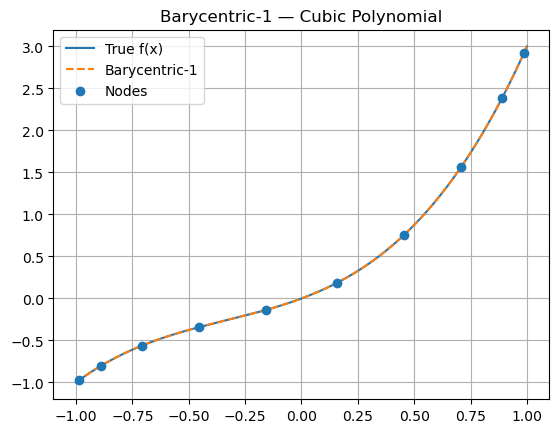


  Function: sin(x)
    Infinity Norm: 4.784317e-11
    MSE: 3.938961e-22
    Max Relative Error: 5.685659e-11
    Mean Absolute Error: 1.537881e-11


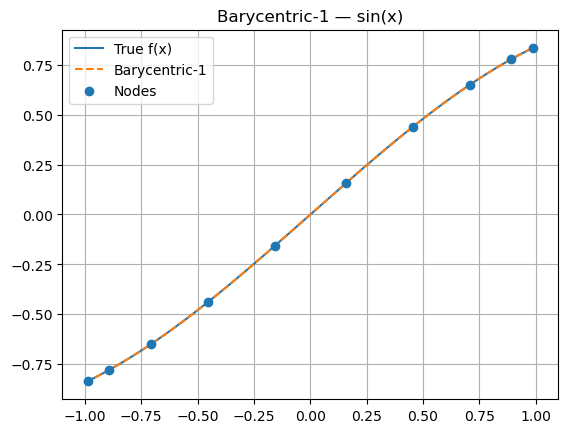


  Function: Runge Function
    Infinity Norm: 2.686689e-01
    MSE: 6.168581e-03
    Max Relative Error: 2.691783e-01
    Mean Absolute Error: 4.753632e-02


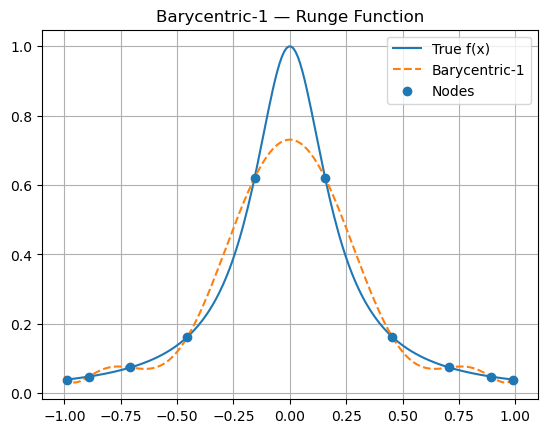


Piecewise Newton Interpolation

  Function: sin(x),  m=3, d=2
    Infinity Norm: 6.844860e-02
    MSE: 1.230705e-03
    Max Relative Error: 5.467171e-01
    Mean Absolute Error: 2.957529e-02


/var/folders/4x/s07wp25s52jb8wrtxxhvq7yc0000gn/T/ipykernel_17098/1117283981.py:18: RuntimeWarning: invalid value encountered in divide
  abs_error / np.abs(true_vals),


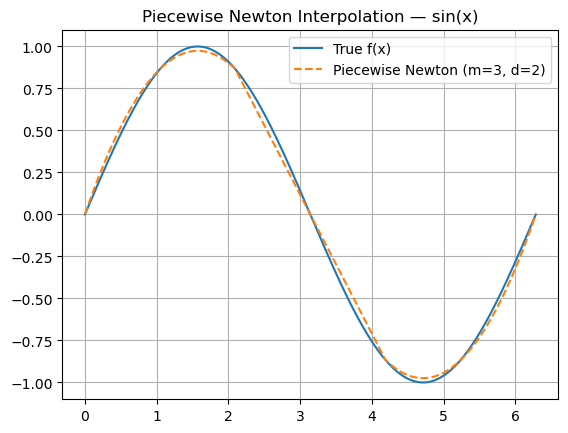


Piecewise Hermite Interpolation

  Function: exp(-x^2),  m=4
    Infinity Norm: 5.099457e-03
    MSE: 7.744857e-06
    Max Relative Error: 5.149692e-02
    Mean Absolute Error: 2.185438e-03


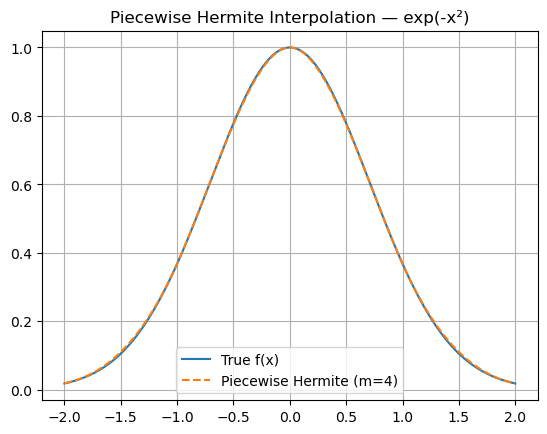


Cubic Spline Interpolation

  Function: x³ - 2x² + x + 1  (BC: S1)
    Infinity Norm: 2.842171e-14
    MSE: 2.291740e-29
    Max Relative Error: 5.865916e-16
    Mean Absolute Error: 2.411404e-15


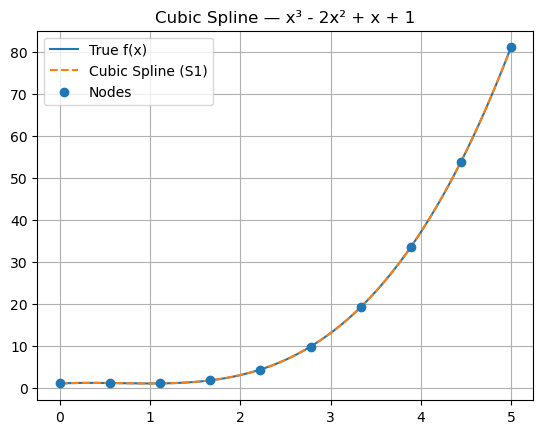


Cubic B-Spline Interpolation

  Function: x³ - 2x² + x + 1  (BC: S1)
    Infinity Norm: 8.793247e-02
    MSE: 8.059531e-04
    Max Relative Error: 7.748124e-02
    Mean Absolute Error: 1.483472e-02


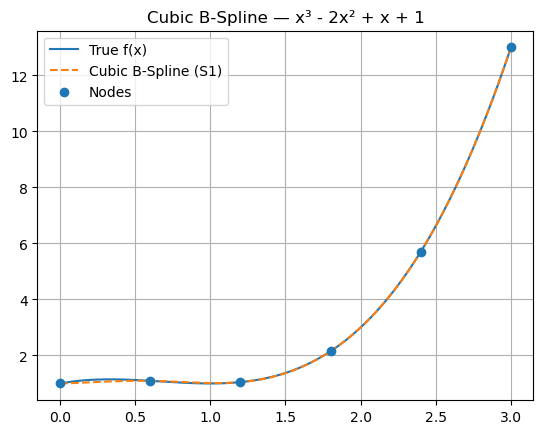

In [47]:
# --- Test Functions ---
functions = {
    "Cubic Polynomial": (lambda x: x**3 + x**2 + x, None),
    "sin(x)":           (lambda x: np.sin(x),         None),
    "Runge Function":   (lambda x: 1/(1 + 25*x**2),   None),
}

hermite_func = (lambda x: np.exp(-x**2), lambda x: -2*x*np.exp(-x**2))
spline_func  = (lambda x: x**3 - 2*x**2 + x + 1, lambda x: 3*x**2 - 4*x + 1)

# define evaluation grids 
eval_pts_global   = np.linspace(-1, 1, 200)
eval_pts_piecewise = np.linspace(0, 2*np.pi, 500)
eval_pts_hermite  = np.linspace(-2, 2, 500)
eval_pts_spline   = np.linspace(0, 5, 300)
eval_pts_bspline  = np.linspace(0, 3, 300)

# Barycentric-1 Interpolation
print("=" * 55)
print("Barycentric-1 Interpolation")
print("=" * 55)

for name, (f, _) in functions.items():
    mesh  = Chebyshev_Points(10)
    fx    = f(mesh)
    gamma = Barycentric1_Coefficients(mesh)
    px    = Barycentric1_Interpolation(eval_pts_global, mesh, gamma, fx)
    true  = f(eval_pts_global)
    stats = Error_Statistics(true, px)

    print(f"\n  Function: {name}")
    for k, v in stats.items():
        print(f"    {k}: {v:.6e}")

    # visualizations
    plt.figure()
    plt.plot(eval_pts_global, true, label="True f(x)")
    plt.plot(eval_pts_global, px, '--', label="Barycentric-1")
    plt.scatter(mesh, fx, zorder=5, label="Nodes")
    plt.title(f"Barycentric-1 — {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

#  Piecewise Newton Interpolation
print("\n" + "=" * 55)
print("Piecewise Newton Interpolation")
print("=" * 55)

f_pw  = lambda x: np.sin(x)
m, d  = 3, 2
pw    = piecewise_interpolation(f_pw, 0, 2*np.pi, m, d, method="uniform", eval_pts=eval_pts_piecewise)
true  = f_pw(eval_pts_piecewise)
stats = Error_Statistics(true, pw)

print(f"\n  Function: sin(x),  m={m}, d={d}")
for k, v in stats.items():
    print(f"    {k}: {v:.6e}")
# visualizations
plt.figure()
plt.plot(eval_pts_piecewise, true, label="True f(x)")
plt.plot(eval_pts_piecewise, pw, '--', label=f"Piecewise Newton (m={m}, d={d})")
plt.title("Piecewise Newton Interpolation — sin(x)")
plt.legend()
plt.grid(True)
plt.show()

# Piecewise Hermite Interpolation
print("\n" + "=" * 55)
print("Piecewise Hermite Interpolation")
print("=" * 55)

f_h, df_h = hermite_func
m_h = 4
herm  = hermite_piecewise_interpolation(f_h, df_h, -2, 2, m_h, eval_pts=eval_pts_hermite)
true  = f_h(eval_pts_hermite)
stats = Error_Statistics(true, herm)

print(f"\n  Function: exp(-x^2),  m={m_h}")
for k, v in stats.items():
    print(f"    {k}: {v:.6e}")

# visualizations
plt.figure()
plt.plot(eval_pts_hermite, true, label="True f(x)")
plt.plot(eval_pts_hermite, herm, '--', label=f"Piecewise Hermite (m={m_h})")
plt.title("Piecewise Hermite Interpolation — exp(-x²)")
plt.legend()
plt.grid(True)
plt.show()

# Cubic Spline Interpolation
print("\n" + "=" * 55)
print("Cubic Spline Interpolation")
print("=" * 55)

f_s, df_s = spline_func
x_mesh = np.linspace(0, 5, 10)
y_mesh = f_s(x_mesh)
params = cubic_spline_param(x_mesh, y_mesh, bc_type='s1', bc_vals=(df_s(x_mesh[0]), df_s(x_mesh[-1])))
cs     = cubic_spline_eval(eval_pts_spline, x_mesh, y_mesh, params)
true   = f_s(eval_pts_spline)
stats  = Error_Statistics(true, cs)

print(f"\n  Function: x³ - 2x² + x + 1  (BC: S1)")
for k, v in stats.items():
    print(f"    {k}: {v:.6e}")

# visualizations
plt.figure()
plt.plot(eval_pts_spline, true, label="True f(x)")
plt.plot(eval_pts_spline, cs, '--', label="Cubic Spline (S1)")
plt.scatter(x_mesh, y_mesh, zorder=5, label="Nodes")
plt.title("Cubic Spline — x³ - 2x² + x + 1")
plt.legend()
plt.grid(True)
plt.show()

# Cubic B-Spline Interpolation
print("\n" + "=" * 55)
print("Cubic B-Spline Interpolation")
print("=" * 55)

x_mesh_b = np.linspace(0, 3, 6)
y_mesh_b  = f_s(x_mesh_b)
xi_centers, alpha = cubic_bspline_param(x_mesh_b, y_mesh_b, bc_type='s1',
                                         bc_vals=(df_s(x_mesh_b[0]), df_s(x_mesh_b[-1])))
bs    = cubic_bspline_eval(eval_pts_bspline, x_mesh_b, xi_centers, alpha)
true  = f_s(eval_pts_bspline)
stats = Error_Statistics(true, bs)

# visualizations
print(f"\n  Function: x³ - 2x² + x + 1  (BC: S1)")
for k, v in stats.items():
    print(f"    {k}: {v:.6e}")

plt.figure()
plt.plot(eval_pts_bspline, true, label="True f(x)")
plt.plot(eval_pts_bspline, bs, '--', label="Cubic B-Spline (S1)")
plt.scatter(x_mesh_b, y_mesh_b, zorder=5, label="Nodes")
plt.title("Cubic B-Spline — x³ - 2x² + x + 1")
plt.legend()
plt.grid(True)
plt.show()

## 5.3 Task2 - Discrete Data Testing \& Validation 
The second task for this program involves recovering the interrelated functions $y(t), f(t)$, and $D(t)$ given only discrete data points.  


| $ t_i $   | 0.5     | 1.0     | 2.0     | 4.0     | 5.0     | 10.0    | 15.0    | 20.0    |
|-------------|---------|---------|---------|---------|---------|---------|---------|---------|
| $ y(t_i) $| 0.0552 | 0.06 | 0.0682 | 0.0801 | 0.0843 | 0.0931 | 0.0912 | 0.0857 |

from $y(t)$ the two derived quantities to recover are 
$$f(t) = y(t) + t\,y'(t), \qquad D(t) = e^{-t\,y(t)}$$

Both $f(t)$ and $D(t)$ require knowledge of $y'(t)$, which is not available from the data. This leads to the choice of interpolating using the natural cubic spline. the primary method used for this experiment is the cubic spline with the S2 natual boundary conditions $s''(x_0) = s''(x_n) = 0 $. The spline is then parameterized on the nonuniform mesh $t_i$ and the derivates are recovered directly from the Hermite basis such that 
$$s'(t) = \frac{1}{h_i}\left(\phi_{00}'(\mu)\,y_i + \phi_{10}'(\mu)\,h_i\,d_i + \phi_{01}'(\mu)\,y_{i+1} + \phi_{11}'(\mu)\,h_i\,d_{i+1}\right)$$
> where μ=(t−xi)/hi\mu = (t - x_i)/h_i
μ=(t−xi​)/hi​ and the basis derivatives are:
> $$\phi_{00}'(\mu) = 6\mu^2 - 6\mu, \quad \phi_{10}'(\mu) = 3\mu^2 - 4\mu + 1, \quad \phi_{01}'(\mu) = -6\mu^2 + 6\mu, \quad \phi_{11}'(\mu) = 3\mu^2 - 2\mu$$

Since the spline is $C^2$ continuous, the derivative is smooth and accurate across all the subintervals, making it well suited for computing $f(t)$ and $D(t)$. 

The piecewise Newton Interpolation was also constructed for the same data. Since Newton's form does not provide a closed form derivative, $y'(t)$ is approximated using np.gradient. This approximation introduces discountiuities at subinterval boundaries which then propgates into $f(t)$ and 

TASK 2: Discrete Data Testing with Nonuniform Mesh
Given data points:
 t =   0.5 y = 0.05520
 t =   1.0 y = 0.06000
 t =   2.0 y = 0.06820
 t =   4.0 y = 0.08010
 t =   5.0 y = 0.08430
 t =  10.0 y = 0.09310
 t =  15.0 y = 0.09120
 t =  20.0 y = 0.08570

Natural Cubic Spline completed.
Piecewise Newton (degree d=1) completed.
Piecewise Newton (degree d=2) completed.
Piecewise Newton (degree d=3) completed.


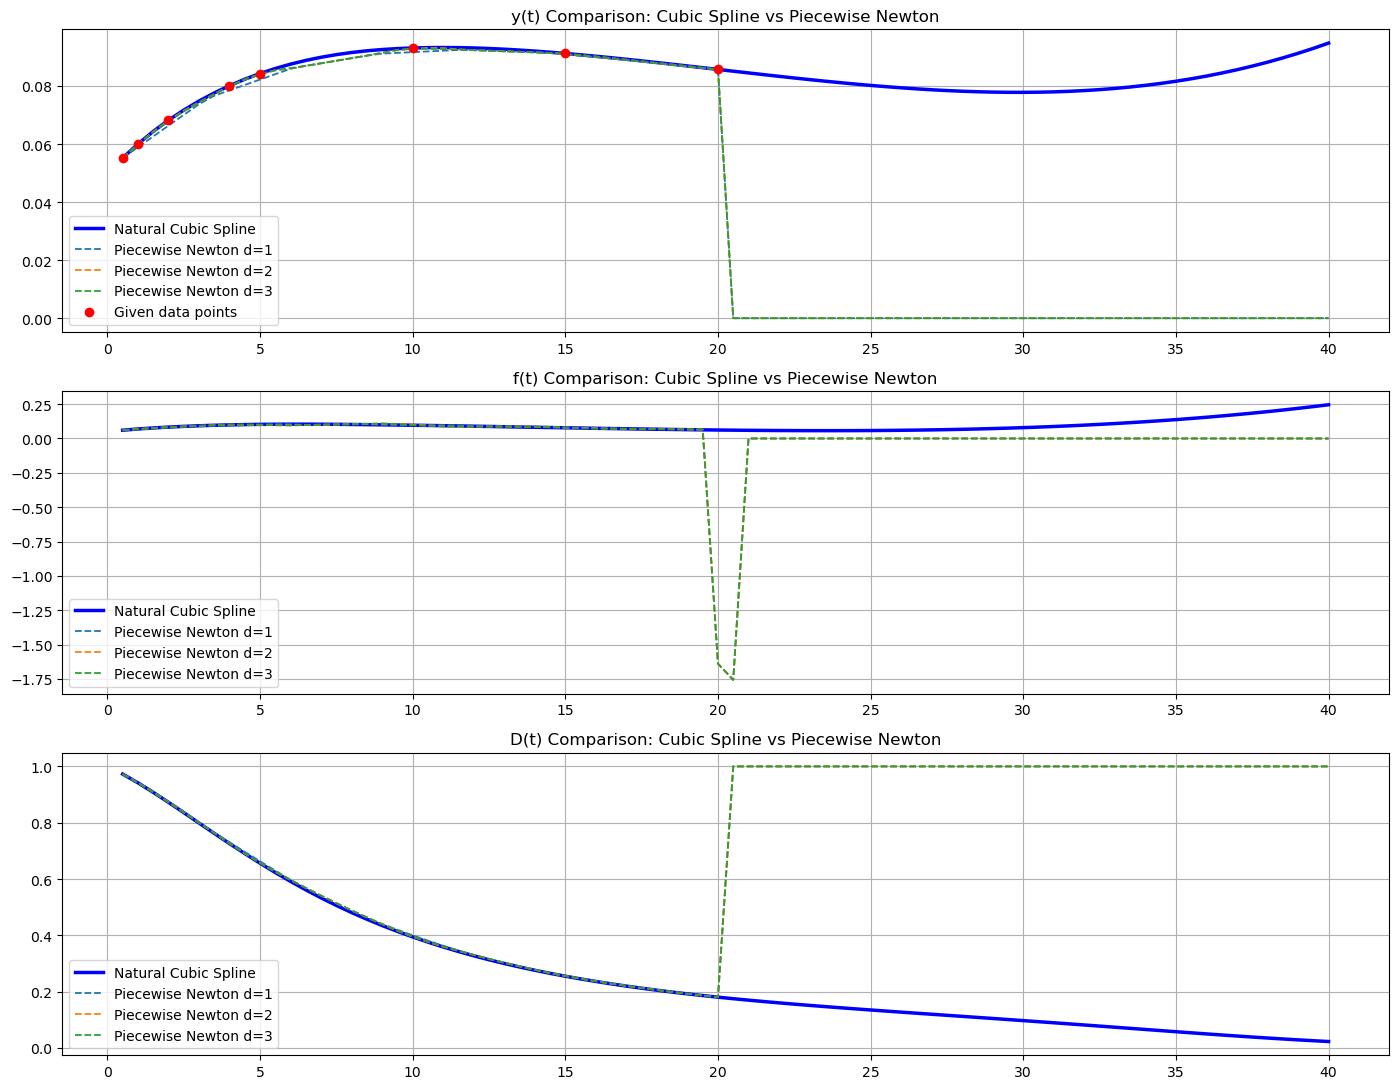

In [48]:
# Discrete Data Testing & Validation
print("="*75)
print("TASK 2: Discrete Data Testing with Nonuniform Mesh")
print("="*75)

# Given discrete data for y(t)
t_data = np.array([0.5, 1.0, 2.0, 4.0, 5.0, 10.0, 15.0, 20.0])
y_data = np.array([0.0552, 0.06, 0.0682, 0.0801, 0.0843, 0.0931, 0.0912, 0.0857])

print("Given data points:")
for ti, yi in zip(t_data, y_data):
    print(f" t = {ti:5.1f} y = {yi:.5f}")

# Evaluation points
t_eval = np.arange(0.5, 40.01, 0.5)

# Natural Cubic Spline 
bc_type = 's2'
bc_vals = (0.0, 0.0) # Natural boundary conditions: s''(0) = s''(end) = 0

d_params = cubic_spline_param(t_data, y_data, bc_type=bc_type, bc_vals=bc_vals)

y_est = cubic_spline_eval(t_eval, t_data, y_data, d_params)
dy_est = cubic_spline_deriv(t_eval, t_data, y_data, d_params)   # ← Your proper analytic derivative
f_est = y_est + t_eval * dy_est
D_est = np.exp(-t_eval * y_est)

print("\nNatural Cubic Spline completed.")

# Piecewise Newton Interpolation (g_d) Comparison
degrees = [1, 2, 3]
pw_results = {}

for d in degrees:
    # Use your existing piecewise_interpolation function
    y_pw = piecewise_interpolation(lambda x: np.interp(x, t_data, y_data),
                                   t_data[0], t_data[-1],
                                   m=len(t_data)-1, s=d,
                                   method="uniform", eval_pts=t_eval)
    
    # Numerical derivative (necessary because piecewise Newton does not provide analytic derivative)
    dy_pw = np.gradient(y_pw, t_eval)
    f_pw = y_pw + t_eval * dy_pw
    D_pw = np.exp(-t_eval * y_pw)
    
    pw_results[d] = (y_pw, f_pw, D_pw)
    print(f"Piecewise Newton (degree d={d}) completed.")

# Plots - Spline vs Piecewise Newton
plt.figure(figsize=(14, 11))

# y(t)
plt.subplot(3, 1, 1)
plt.plot(t_eval, y_est, 'b-', linewidth=2.5, label='Natural Cubic Spline')
for d in degrees:
    plt.plot(t_eval, pw_results[d][0], '--', linewidth=1.3, label=f'Piecewise Newton d={d}')
plt.plot(t_data, y_data, 'ro', markersize=6, label='Given data points')
plt.title('y(t) Comparison: Cubic Spline vs Piecewise Newton')
plt.legend()
plt.grid(True)

# f(t)
plt.subplot(3, 1, 2)
plt.plot(t_eval, f_est, 'b-', linewidth=2.5, label='Natural Cubic Spline')
for d in degrees:
    plt.plot(t_eval, pw_results[d][1], '--', linewidth=1.3, label=f'Piecewise Newton d={d}')
plt.title('f(t) Comparison: Cubic Spline vs Piecewise Newton')
plt.legend()
plt.grid(True)

# D(t)
plt.subplot(3, 1, 3)
plt.plot(t_eval, D_est, 'b-', linewidth=2.5, label='Natural Cubic Spline')
for d in degrees:
    plt.plot(t_eval, pw_results[d][2], '--', linewidth=1.3, label=f'Piecewise Newton d={d}')
plt.title('D(t) Comparison: Cubic Spline vs Piecewise Newton')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 6. Conclusion 
This project successfully implements and analyzes several important interpolation techniques. Each method was tested on smooth functions that demonstrate the strenghts and weaknesses associated with each of the methods. 

The global Barycentric-1 method performed well with chebyshev nodes, while piecewise methods offered improved local control. The cubic splines in both forms consistently delivered the best combination of accuracy and smoothness. 

In the discrete data task, the natural cubic spline was used to recover the functions from the nonuniformly spaced measurements of $y(t_i)$. The spline produced a smooth $C^2$ continuous interpolating function with a reliable derivative. In comparison the piecewise Newton interpolation for varying degrees suffered from the discontinuities of the derivatives at the data nodes. 

The results from this project show that when a differentiable interpolant is needed, the cubic spline outperforms piecewise polynomial methods due to the global smoothness and numerical stability. While higher degree piecewise interpolants cannot overcome the lack of derivative continuity without modifications. 